In [ ]:
#  Cell 1: Imports & general configuration (using ../data_final) 

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
import joblib
import sklearn, matplotlib

DATA_DIR = Path("../data_final").resolve()

# Display options
pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.figsize"] = (6, 4)


print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)


print("Resolved DATA_DIR:", DATA_DIR)



Python: 3.11.9
pandas: 2.3.2
scikit-learn: 1.7.1
matplotlib: 3.10.6
Resolved DATA_DIR: C:\TienDatNguyen_Data_Collection_and_Processing\data_final


In [8]:
# Cell 2: Load train/test datasets and quick inspection 
from IPython.display import display


train_path = (DATA_DIR / "train.csv").resolve()
test_path  = (DATA_DIR / "test.csv").resolve()


assert train_path.exists(), f"File not found: {train_path}"
assert test_path.exists(),  f"File not found: {test_path}"


df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)


print("Train shape:", df_train.shape)
print("Test  shape:", df_test.shape)
print("\nTrain columns:", list(df_train.columns))
print("Test  columns:", list(df_test.columns))


print("\n Preview: train.csv (5 rows)")
display(df_train.head(5))

print("\n Preview: test.csv (5 rows)")
display(df_test.head(5))

# check missing values in training set
print("\n Missing values (train)")
display(df_train.isna().sum().to_frame("missing"))


Train shape: (4133, 3)
Test  shape: (1034, 3)

Train columns: ['text', 'text_clean', 'label']
Test  columns: ['text', 'text_clean', 'label']

 Preview: train.csv (5 rows)


,text,text_clean,label
0,Actually I decided I was too hungry so I haven't left yet :V,actually i decided i was too hungry so i haven t left yet v,0
1,"This is one of the days you have a billion classes, right?",this is one of the days you have a billion classes right,0
2,Ok lor then we go tog lor...,ok lor then we go tog lor,0
3,"I can probably come by, everybody's done around &lt;#&gt; right?",i can probably come by everybody s done around lt gt right,0
4,18 days to Euro2004 kickoff! U will be kept informed of all the latest news and results daily. Unsubscribe send GET EURO STOP to 83222.,[num] days to euro [num] kickoff u will be kept informed of all the latest news and results daily unsubscribe send get euro stop to [num],1



 Preview: test.csv (5 rows)


,text,text_clean,label
0,HI ITS KATE CAN U GIVE ME A RING ASAP XXX,hi its kate can u give me a ring asap xxx,0
1,"Yeah, probably here for a while",yeah probably here for a while,0
2,Olol i printed out a forum post by a guy with the exact same prob which was fixed with a gpu replacement. Hopefully they dont ignore that.,olol i printed out a forum post by a guy with the exact same prob which was fixed with a gpu replacement hopefully they dont ignore that,0
3,Your right! I'll make the appointment right now.,your right i ll make the appointment right now,0
4,Sorry i missed your call. Can you please call back.,sorry i missed your call can you please call back,0



 Missing values (train)


,missing
text,0
text_clean,0
label,0


In [9]:
# Cell 3: Select text/label columns and split into train/validation 

PREFERRED_TEXT_COLS = ["text_clean", "text", "message", "content", "sms"]
PREFERRED_LABEL_COLS = ["label", "target", "y", "class"]

def pick_column(df, preferred_names):
    for name in preferred_names:
        if name in df.columns:
            return name
    raise ValueError(f"Could not find any of these columns in dataframe: {preferred_names}")


TEXT_COL  = pick_column(df_train, PREFERRED_TEXT_COLS)
LABEL_COL = pick_column(df_train, PREFERRED_LABEL_COLS)

print(f"Using TEXT_COL = '{TEXT_COL}' | LABEL_COL = '{LABEL_COL}'")

# Basic sanity checks
assert df_train[TEXT_COL].dtype == object, "Text column should be string-like."
assert df_train[LABEL_COL].nunique() <= 2, "Expecting binary labels (0/1)."

# Train/validation split (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    df_train[TEXT_COL],
    df_train[LABEL_COL],
    test_size=0.2,
    random_state=42,
    stratify=df_train[LABEL_COL]
)

# Prepare test set
X_test = df_test[TEXT_COL]
y_test = df_test[LABEL_COL] if LABEL_COL in df_test.columns else None  # test may or may not have labels


print("\nLabel distribution (train):")
print(y_train.value_counts(normalize=True).rename("ratio"))

print("\nLabel distribution (val):")
print(y_val.value_counts(normalize=True).rename("ratio"))

if y_test is not None:
    print("\nLabel distribution (test):")
    print(y_test.value_counts(normalize=True).rename("ratio"))
else:
    print("\nTest set has no labels; will only generate predictions later.")



Using TEXT_COL = 'text_clean' | LABEL_COL = 'label'

Label distribution (train):
label
0    0.873563
1    0.126437
Name: ratio, dtype: float64

Label distribution (val):
label
0    0.874244
1    0.125756
Name: ratio, dtype: float64

Label distribution (test):
label
0    0.873308
1    0.126692
Name: ratio, dtype: float64


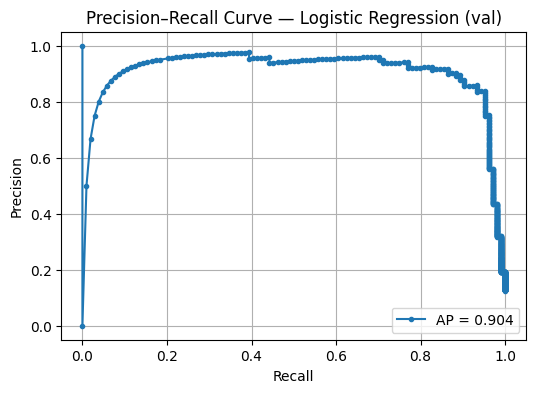

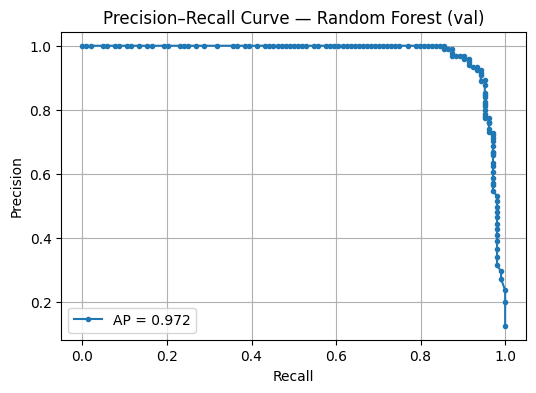

In [29]:
# Cell 6: Precision–Recall Curves (validation) 
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

def plot_pr_curve(model, X, y, title: str):
    # Get predicted probabilities for the positive class (label = 1)
    y_scores = model.predict_proba(X)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y, y_scores)
    ap = average_precision_score(y, y_scores)

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, marker=".", label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {title}")
    plt.legend()
    plt.grid(True)
    plt.show()

# Validation curves
plot_pr_curve(logreg_pipe, X_val, y_val, "Logistic Regression (val)")
plot_pr_curve(rf_pipe,     X_val, y_val, "Random Forest (val)")


In [28]:
#  Cell 4: Build pipelines, train, and evaluate on validation 
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

# Define two baseline pipelines
logreg_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000))
])

rf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

# Train models
logreg_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

# Helper evaluation function
def evaluate(model, X, y, name: str):
    y_pred = model.predict(X)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)
    f1   = f1_score(y, y_pred, zero_division=0)
    print(f"{name} | Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}")
    print(classification_report(y, y_pred, digits=3))
    return {"y_pred": y_pred, "acc": acc, "prec": prec, "rec": rec, "f1": f1}

print("Validation results")
metrics_log = evaluate(logreg_pipe, X_val, y_val, "LogisticRegression (val)")
metrics_rf  = evaluate(rf_pipe,     X_val, y_val, "RandomForest (val)")


Validation results
LogisticRegression (val) | Acc: 0.9649  Prec: 0.9213  Rec: 0.7885  F1: 0.8497
              precision    recall  f1-score   support

           0      0.970     0.990     0.980       723
           1      0.921     0.788     0.850       104

    accuracy                          0.965       827
   macro avg      0.946     0.889     0.915       827
weighted avg      0.964     0.965     0.964       827

RandomForest (val) | Acc: 0.9746  Prec: 1.0000  Rec: 0.7981  F1: 0.8877
              precision    recall  f1-score   support

           0      0.972     1.000     0.986       723
           1      1.000     0.798     0.888       104

    accuracy                          0.975       827
   macro avg      0.986     0.899     0.937       827
weighted avg      0.975     0.975     0.973       827



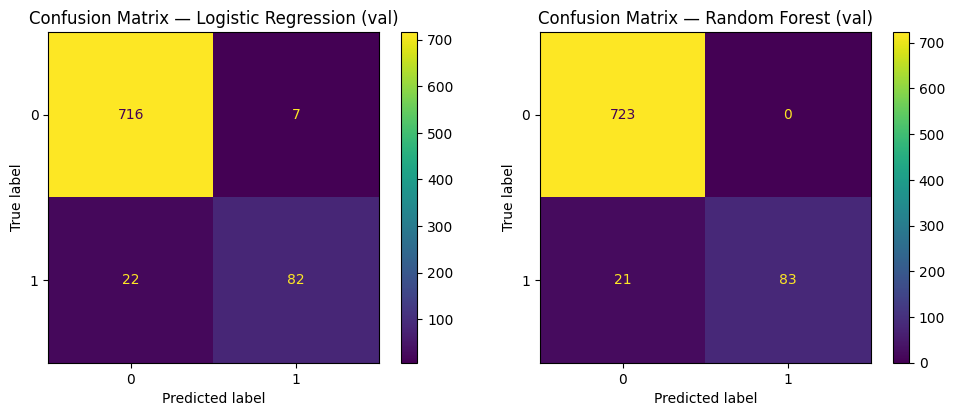

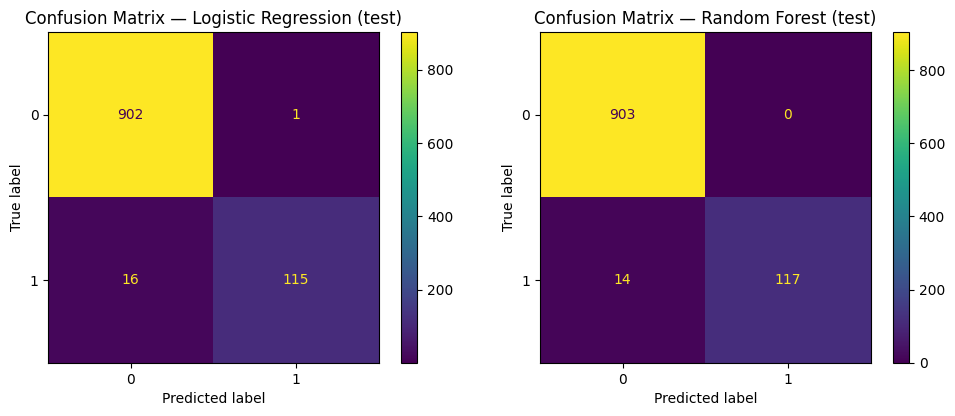

In [ ]:
# Cell 5: Plot confusion matrices (validation & test) 
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Validation confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_val, logreg_pipe.predict(X_val), labels=[0, 1], ax=axes[0]
)
axes[0].set_title("Confusion Matrix — Logistic Regression (val)")

ConfusionMatrixDisplay.from_predictions(
    y_val, rf_pipe.predict(X_val), labels=[0, 1], ax=axes[1]
)
axes[1].set_title("Confusion Matrix — Random Forest (val)")

plt.tight_layout()
plt.show()

# Test confusion matrices (only if test labels exist)
if y_test is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test, logreg_pipe.predict(X_test), labels=[0, 1], ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix — Logistic Regression (test)")

    ConfusionMatrixDisplay.from_predictions(
        y_test, rf_pipe.predict(X_test), labels=[0, 1], ax=axes[1]
    )
    axes[1].set_title("Confusion Matrix — Random Forest (test)")

    plt.tight_layout()
    plt.show()
else:
    print("Test set has no labels — skipping test confusion matrices.")


Chosen threshold to target recall ≥ 0.90: 0.2185 (est. Precision=0.879, Recall=0.904, F1=0.891, met_target=True)
LogReg (val) — target Recall @thr=0.218 | Acc 0.9722  Prec 0.8785  Rec 0.9038  F1 0.8910
              precision    recall  f1-score   support

           0      0.986     0.982     0.984       723
           1      0.879     0.904     0.891       104

    accuracy                          0.972       827
   macro avg      0.932     0.943     0.938       827
weighted avg      0.973     0.972     0.972       827



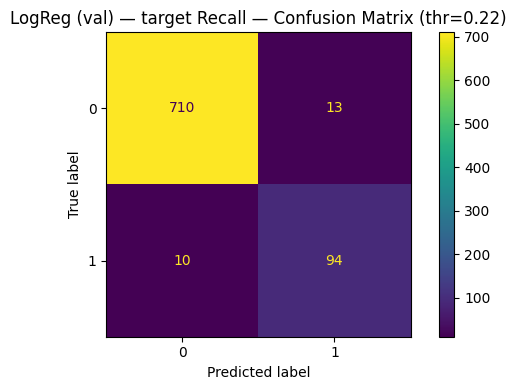

In [ ]:
#  Cell 7: Tune threshold to reach target Recall (e.g., ≥ 0.90) 
import numpy as np
from sklearn.metrics import (
    precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Sanity checks (ensure previous cells ran)
assert 'logreg_pipe' in globals() and 'X_val' in globals() and 'y_val' in globals(), \
    "Run Cells 3–4 first (X_val/y_val/logreg_pipe not defined)."

def pick_threshold_by_target_recall(y_true, y_prob, target_recall=0.90):
    """Pick the highest threshold that still achieves recall >= target_recall."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    # thresholds length = len(precision) - 1
    idxs = np.where(recall[:-1] >= target_recall)[0]
    if len(idxs) == 0:
        # If target recall is not reachable, fall back to the threshold that maximizes F1
        f1s = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
        best_idx = np.nanargmax(f1s)
        return thresholds[best_idx], precision[best_idx], recall[best_idx], f1s[best_idx], False
   
    idx = idxs[-1]
    f1_val = (2 * precision[idx] * recall[idx]) / (precision[idx] + recall[idx] + 1e-12)
    return thresholds[idx], precision[idx], recall[idx], f1_val, True

def evaluate_with_threshold(y_true, y_prob, threshold, title=""):
    """Evaluate metrics at a given threshold and plot confusion matrix."""
    y_pred = (y_prob >= threshold).astype(int)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"{title} @thr={threshold:.3f} | Acc {acc:.4f}  Prec {prec:.4f}  Rec {rec:.4f}  F1 {f1:.4f}")
    print(classification_report(y_true, y_pred, digits=3))

    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, labels=[0, 1])
    plt.title(f"{title} — Confusion Matrix (thr={threshold:.2f})")
    plt.tight_layout()
    plt.show()
    return y_pred, (acc, prec, rec, f1)

# Get validation probabilities from Logistic Regression
y_val_prob_log = logreg_pipe.predict_proba(X_val)[:, 1]

# Pick threshold to achieve target Recall 
target_recall = 0.90
thr, p_est, r_est, f1_est, met_target = pick_threshold_by_target_recall(
    y_val, y_val_prob_log, target_recall=target_recall
)
print(f"Chosen threshold to target recall ≥ {target_recall:.2f}: {thr:.4f} "
      f"(est. Precision={p_est:.3f}, Recall={r_est:.3f}, F1={f1_est:.3f}, met_target={met_target})")

# Evaluate at this threshold on validation set
_ = evaluate_with_threshold(y_val, y_val_prob_log, thr, title="LogReg (val) — target Recall")


LogReg (test) — default @thr=0.500 | Acc 0.9836  Prec 0.9914  Rec 0.8779  F1 0.9312
              precision    recall  f1-score   support

           0      0.983     0.999     0.991       903
           1      0.991     0.878     0.931       131

    accuracy                          0.984      1034
   macro avg      0.987     0.938     0.961      1034
weighted avg      0.984     0.984     0.983      1034

LogReg (test) — tuned @thr=0.218 | Acc 0.9836  Prec 0.9191  Rec 0.9542  F1 0.9363
              precision    recall  f1-score   support

           0      0.993     0.988     0.991       903
           1      0.919     0.954     0.936       131

    accuracy                          0.984      1034
   macro avg      0.956     0.971     0.963      1034
weighted avg      0.984     0.984     0.984      1034



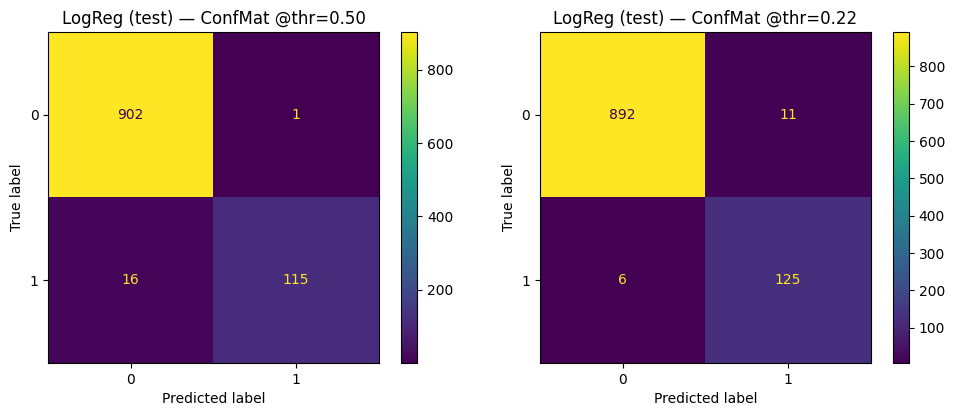


Saved CHOSEN_THRESHOLD = 0.2185 for later use.


In [ ]:
# Cell 8: Apply tuned threshold on the test set (compare vs. 0.5)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)


assert 'logreg_pipe' in globals(), "Run Cell 4 to fit Logistic Regression."
assert 'X_test' in globals(), "Run Cell 3 to prepare X_test."
assert 'thr' in globals(), "Run Cell 7 to get a tuned threshold (variable 'thr')."

# If test labels are available we can compute metrics; otherwise we only output predictions
has_test_labels = ('y_test' in globals()) and (y_test is not None)

def eval_at_threshold(y_true, y_prob, thr_value, name=""):
    """Evaluate metrics at a given threshold and (optionally) plot confusion matrix."""
    y_pred = (y_prob >= thr_value).astype(int)
    if has_test_labels:
        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)
        print(f"{name} @thr={thr_value:.3f} | Acc {acc:.4f}  Prec {prec:.4f}  Rec {rec:.4f}  F1 {f1:.4f}")
        print(classification_report(y_true, y_pred, digits=3))
    else:
        print(f"{name} @thr={thr_value:.3f} | Test labels unavailable; generated predictions only.")
    return y_pred

# Get test probabilities from Logistic Regression (positive class = 1)
y_test_prob_log = logreg_pipe.predict_proba(X_test)[:, 1]

# Evaluate at default threshold 0.5
y_test_pred_default = eval_at_threshold(
    y_test if has_test_labels else None, y_test_prob_log, 0.50, name="LogReg (test) — default"
)

# Evaluate at tuned threshold from validation (thr)
y_test_pred_tuned = eval_at_threshold(
    y_test if has_test_labels else None, y_test_prob_log, thr, name="LogReg (test) — tuned"
)

# Plot confusion matrices side-by-side (only if test labels exist)
if has_test_labels:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_default, labels=[0, 1], ax=axes[0])
    axes[0].set_title("LogReg (test) — ConfMat @thr=0.50")

    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_tuned, labels=[0, 1], ax=axes[1])
    axes[1].set_title(f"LogReg (test) — ConfMat @thr={thr:.2f}")

    plt.tight_layout()
    plt.show()

# Keep the chosen threshold for later saving (Cell 9)
CHOSEN_THRESHOLD = float(thr)
print(f"\nSaved CHOSEN_THRESHOLD = {CHOSEN_THRESHOLD:.4f} for later use.")


In [ ]:
# Cell 9: Save model pipeline and chosen threshold 
from pathlib import Path
import json
import joblib
import sys, pandas as pd, sklearn, numpy as np


assert 'logreg_pipe' in globals(), "Model pipeline not found — run Cell 4."
assert 'CHOSEN_THRESHOLD' in globals(), "Threshold not set — run Cell 8."

# Create a models/ folder (relative to the notebook)
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# File paths
MODEL_PATH = MODELS_DIR / "sms_logreg_pipeline.joblib"
THRESHOLD_PATH = MODELS_DIR / "sms_logreg_threshold.json"
METADATA_PATH = MODELS_DIR / "sms_logreg_metadata.json"

# Save the full pipeline (TF-IDF + LogisticRegression)
joblib.dump(logreg_pipe, MODEL_PATH)
print(f"Saved model pipeline to: {MODEL_PATH.resolve()}")

# Save threshold (float)
with open(THRESHOLD_PATH, "w", encoding="utf-8") as f:
    json.dump({"threshold": float(CHOSEN_THRESHOLD)}, f, ensure_ascii=False, indent=2)
print(f"Saved tuned threshold to: {THRESHOLD_PATH.resolve()}")

# Save metadata for reproducibility
metadata = {
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "numpy": np.__version__,
    "model_file": str(MODEL_PATH.name),
    "threshold_file": str(THRESHOLD_PATH.name),
    "threshold": float(CHOSEN_THRESHOLD),
    "text_column": TEXT_COL,
    "label_column": LABEL_COL,
    "notes": "Pipeline = TF-IDF(1–2 grams, max_features=5000) + LogisticRegression(max_iter=1000)."
}
with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"Saved metadata to: {METADATA_PATH.resolve()}")


Saved model pipeline to: C:\TienDatNguyen_Data_Collection_and_Processing\models\sms_logreg_pipeline.joblib
Saved tuned threshold to: C:\TienDatNguyen_Data_Collection_and_Processing\models\sms_logreg_threshold.json
Saved metadata to: C:\TienDatNguyen_Data_Collection_and_Processing\models\sms_logreg_metadata.json


In [ ]:
# Inspect saved model final data evaluation
from pathlib import Path
import joblib

MODEL_PATH = Path("../models/sms_logreg_pipeline.joblib")

assert MODEL_PATH.exists(), f"Model file not found: {MODEL_PATH.resolve()}"

pipe = joblib.load(MODEL_PATH)
print(pipe)

tfidf = pipe.named_steps.get("tfidf")
clf   = pipe.named_steps.get("clf")
if tfidf is not None:
    print("\nTF-IDF params:", tfidf.get_params())
    try:
        feat_names = tfidf.get_feature_names_out()
        print("Num features:", len(feat_names))
        print("Sample features:", feat_names[:20])
    except Exception as e:
        print("Could not list feature names:", e)

if clf is not None:
    print("\nClassifier params:", clf.get_params())


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000))])

TF-IDF params: {'analyzer': 'word', 'binary': False, 'decode_error': 'strict', 'dtype': <class 'numpy.float64'>, 'encoding': 'utf-8', 'input': 'content', 'lowercase': True, 'max_df': 1.0, 'max_features': 5000, 'min_df': 1, 'ngram_range': (1, 2), 'norm': 'l2', 'preprocessor': None, 'smooth_idf': True, 'stop_words': None, 'strip_accents': None, 'sublinear_tf': False, 'token_pattern': '(?u)\\b\\w\\w+\\b', 'tokenizer': None, 'use_idf': True, 'vocabulary': None}
Num features: 5000
Sample features: ['abi' 'abiola' 'able' 'able to' 'about' 'about how' 'about it' 'about me'
 'about num' 'about smiling' 'about stuff' 'about that' 'about the'
 'about this' 'about you' 'abt' 'ac' 'acc' 'accept' 'account']

Classifier params: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, '